In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix
from sklearn.ensemble import RandomForestClassifier

In [4]:
df=pd.read_csv('student_performance.csv')
print(df.head())
print(df.isnull().sum())


   StudyHours  Attendance  Resources  Extracurricular  Motivation  Internet  \
0          19          64          1                0           0         1   
1          19          64          1                0           0         1   
2          19          64          1                0           0         1   
3          19          64          1                1           0         1   
4          19          64          1                1           0         1   

   Gender  Age  LearningStyle  OnlineCourses  Discussions  \
0       0   19              2              8            1   
1       0   23              3             16            0   
2       0   28              1             19            0   
3       0   19              2              8            1   
4       0   23              3             16            0   

   AssignmentCompletion  ExamScore  EduTech  StressLevel  FinalGrade  
0                    59         40        0            1           3  
1               

In [5]:
X=df.drop(columns='FinalGrade')
y=df['FinalGrade']

<Axes: >

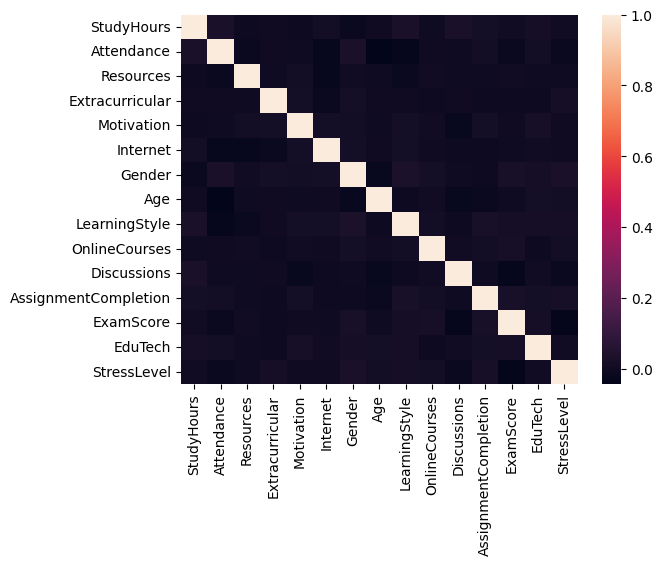

In [6]:
sns.heatmap(X.corr())


In [7]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

In [8]:
X_train,X_test,y_train,y_test=train_test_split(X_scaled, y, test_size=0.2,random_state=42)

In [13]:
model=LogisticRegression()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
print('Accuracy = ',accuracy_score(y_test,y_pred))
print('Precision = ',precision_score(y_test,y_pred,average='weighted'))
print('Recall = ',precision_score(y_test,y_pred,average='weighted'))
print('F1 Score = ',f1_score(y_test,y_pred,average='weighted'))
print('Confusion Matrix = \n',confusion_matrix(y_test,y_pred))

Accuracy =  0.9935737236701179
Precision =  0.9936300245841378
Recall =  0.9936300245841378
F1 Score =  0.9935797136007609
Confusion Matrix = 
 [[782   3   0   0]
 [  2 639   6   0]
 [  0   1 701   0]
 [  0   0   6 661]]


In [14]:
rf=RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(X_train,y_train)
rf_pred=rf.predict(X_test)

In [15]:
print("RF Accuracy = ",accuracy_score(y_test,rf_pred))


RF Accuracy =  1.0


In [16]:
importance=pd.DataFrame({'Features':X.columns,'Importance':rf.feature_importances_})
print(importance)

                Features  Importance
0             StudyHours    0.033395
1             Attendance    0.036641
2              Resources    0.005482
3        Extracurricular    0.003647
4             Motivation    0.005716
5               Internet    0.001996
6                 Gender    0.007381
7                    Age    0.026583
8          LearningStyle    0.015829
9          OnlineCourses    0.033072
10           Discussions    0.006783
11  AssignmentCompletion    0.038674
12             ExamScore    0.766318
13               EduTech    0.007424
14           StressLevel    0.011061


In [17]:
from sklearn.cluster import KMeans
X=df

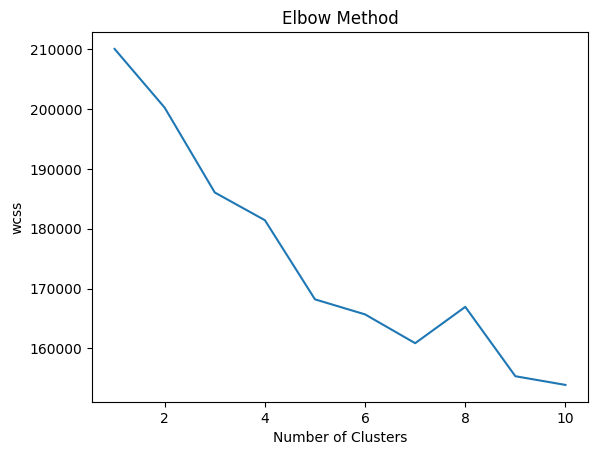

In [18]:
wcss=[]
for i in range(1,11):
  kmeans=KMeans(n_clusters=i,random_state=42)
  kmeans.fit(X_scaled)
  wcss.append(kmeans.inertia_)
plt.plot(range(1,11),wcss)
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('wcss')
plt.show()

In [19]:
kmeans=KMeans(n_clusters=5,init='k-means++',random_state=42)
y_kmeans=kmeans.fit_predict(X_scaled)
df['Clusters']=y_kmeans

[[-1.90398506 -0.42209749]
 [ 0.47749411 -1.19935096]
 [ 0.27232384 -2.0113788 ]
 ...
 [-1.167382    0.68933159]
 [-0.18780953 -1.24941215]
 [ 0.11328086  0.13645578]]


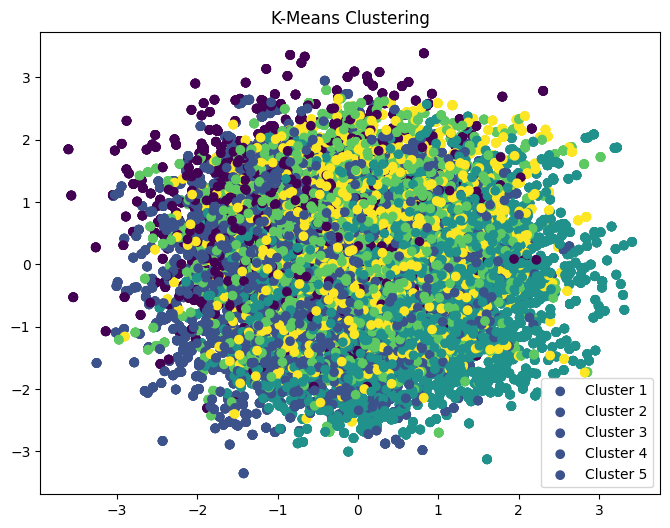

In [20]:
plt.figure(figsize=(8,6))
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
X_pca=pca.fit_transform(X_scaled)
print(X_pca)
for i in range(1,6):
  plt.scatter(X_pca[:,0],X_pca[:,1],c=y_kmeans,label=f'Cluster {i}')
plt.legend()
plt.title('K-Means Clustering')
plt.show()

In [21]:
summary=df.groupby('Clusters').mean(numeric_only=True)
summary

,StudyHours,Attendance,Resources,Extracurricular,Motivation,Internet,Gender,Age,LearningStyle,OnlineCourses,Discussions,AssignmentCompletion,ExamScore,EduTech,StressLevel,FinalGrade
Clusters,,,,,,,,,,,,,,,,
0,19.849473,81.251198,1.162991,0.625120,0.881112,0.0,0.535954,23.549377,1.479386,9.903164,0.619367,74.918504,70.665388,0.701822,1.312560,1.422819
1,19.861281,79.992293,1.099123,0.600319,0.884932,1.0,0.540792,23.445655,1.495349,10.019134,0.602179,74.229073,69.985118,0.000000,1.295243,1.477545
2,19.914759,80.121931,1.103172,0.592276,0.922483,1.0,0.553379,23.752552,1.528828,9.820138,0.000000,74.650759,70.899586,1.000000,1.339310,1.396690
3,20.144390,80.028204,1.091355,1.000000,0.925812,1.0,0.566830,23.453096,1.519926,9.777131,1.000000,74.485592,70.291539,1.000000,1.295831,1.456775
4,20.147619,80.394372,1.106926,0.000000,0.896537,1.0,0.554113,23.431169,1.537229,9.954545,1.000000,74.551515,70.003463,1.000000,1.272727,1.478788


In [22]:
from sklearn.metrics import silhouette_score
print('Silhouette score = ',silhouette_score(X_scaled,y_kmeans))

Silhouette score =  0.0662036596881294


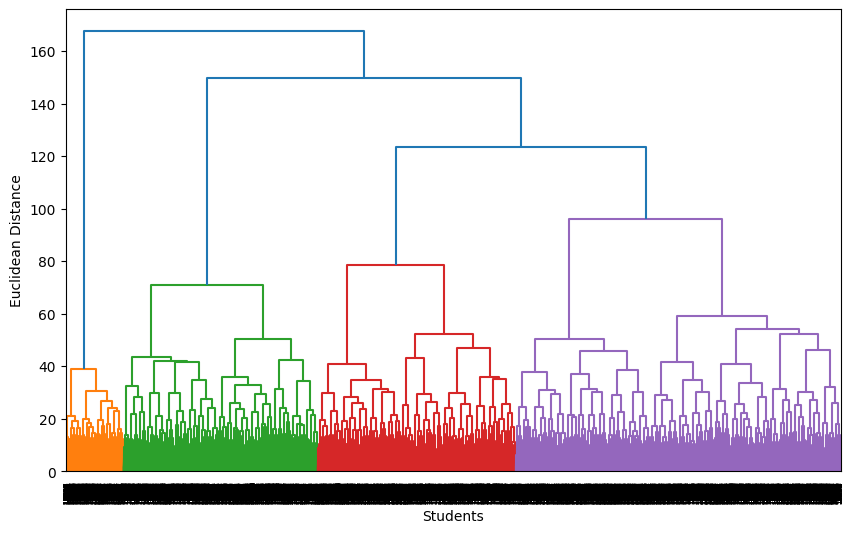

In [23]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram,linkage
plt.figure(figsize=(10,6))
dendrogram(linkage(X_scaled,method = 'ward'))
plt.xlabel('Students')
plt.ylabel('Euclidean Distance')
plt.show()

In [24]:
hc=AgglomerativeClustering(n_clusters=5,linkage='ward')
y_hc=hc.fit_predict(X_scaled)
df['Cluster']=y_hc

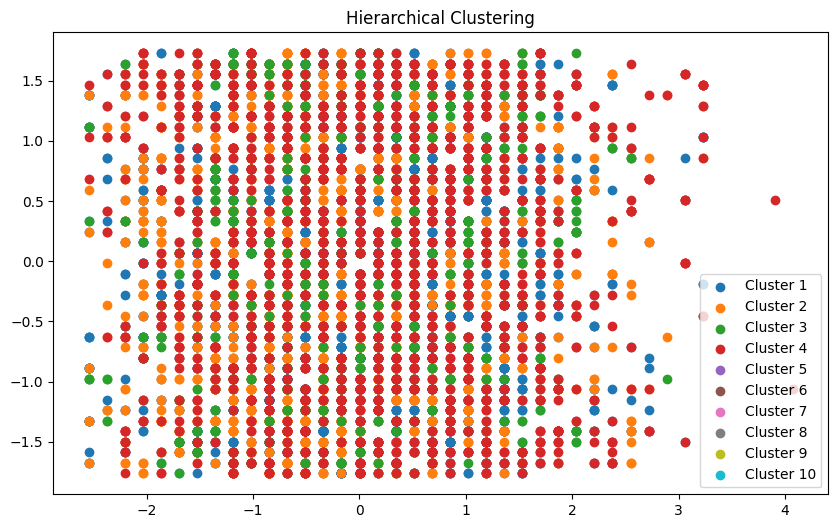

In [25]:
plt.figure(figsize=(10,6))
for i in range(1,11):
  plt.scatter(X_scaled[y_hc==i,0],X_scaled[y_hc==i,1],label=f'Cluster {i}')
plt.legend()
plt.title('Hierarchical Clustering')
plt.show()

In [26]:
hc_score=silhouette_score(X_scaled,y_hc)
print('HC Silhouette Score = ',hc_score)

HC Silhouette Score =  0.05547420695929428


In [27]:
hc_summary=df.groupby('Cluster').mean(numeric_only=True)
print('HC Summary = \n',hc_summary)

HC Summary = 
          StudyHours  Attendance  Resources  Extracurricular  Motivation  \
Cluster                                                                   
0         20.341709   80.510050   1.075098         0.608878    0.914015   
1         19.940937   79.044516   1.121036         0.569101    0.946465   
2         19.399147   80.339972   1.102134         0.607397    0.886202   
3         19.849473   81.251198   1.162991         0.625120    0.881112   
4         20.441880   80.691674   1.102226         0.575433    0.875103   

         Internet    Gender        Age  LearningStyle  OnlineCourses  \
Cluster                                                                
0             1.0  0.580681  23.739252       1.447236       9.645170   
1             1.0  0.912715  23.572592       1.712831      10.019203   
2             1.0  0.525747  23.239260       1.527169      10.143385   
3             0.0  0.535954  23.549377       1.479386       9.903164   
4             1.0  0.043281

In [28]:
from sklearn.cluster import DBSCAN
dbscan=DBSCAN(eps=0.5, min_samples=5)
y_db=dbscan.fit_predict(X_scaled)
df['DB Clusters']=y_db

In [29]:
db_score=silhouette_score(X_scaled,y_db)
print('DB Score =',db_score)

DB Score = -0.15603519820350614


In [30]:
db_summary=df.groupby('DB Clusters').mean(numeric_only=True)
print('DB Summary= \n',db_summary)

DB Summary= 
              StudyHours  Attendance  Resources  Extracurricular  Motivation  \
DB Clusters                                                                   
-1            19.988852   80.184449   1.104481         0.593868    0.905739   
 0            18.000000   94.000000   1.000000         1.000000    1.000000   
 1            18.000000   94.000000   1.000000         1.000000    1.000000   

             Internet    Gender        Age  LearningStyle  OnlineCourses  \
DB Clusters                                                                
-1           0.925463  0.552348  23.532195       1.515115       9.894733   
 0           1.000000  0.000000  27.000000       2.000000       4.000000   
 1           1.000000  0.000000  20.000000       2.000000       8.000000   

             Discussions  AssignmentCompletion  ExamScore   EduTech  \
DB Clusters                                                           
-1              0.605946             74.498964  70.361109  0.708854